
# 13. 스스로 성장 결정하기: 언제 새 부품을 키울까

**문제 흐름** (예고 없음): 200문제짜리 구간 40개, 문제마다 정답 공개
- 구간 1–10: 기존 표현의 고리 문제
- 구간 11–20: + **새 말투** ("열쇠가 매한가지야") → 옛 생각 루프가 그대로 풂 → **키우면 낭비**
- 구간 21–40: + **다음 차례** ("파란 문 열쇠는 빨간 문 열쇠의 다음 차례야") → 옛 생각 루프는 구조상 못 풂 → **키워야 함**

**성장 방식**: 결정하면 공부 자료 1,000문제를 모아서, 얼린 생각 루프에 "다음 차례" 가지(6,170개)를 키워 붙인다.

| 방식 | 언제 키우나 |
|---|---|
| 안 키움 | — |
| **실패율 (우리)** | 틀렸거나 "모름"이라고 했는데 답이 있었던 비율이 2구간 연속 5%를 넘을 때 |
| 새로움 | 처음 보는 문장이 섞인 문제가 2구간 연속 5%를 넘을 때 |
| 이상적 | 구간 21에 바뀐다는 걸 앎 |


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
SEEDS = (45, 46, 47)
runs = {s: json.loads((S.RESULTS / f"world-v8_stream_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
for s in SEEDS:
    print(s, {p: (v["phase3_late"], [g[0] for g in v["growths"]]) for p, v in runs[s]["summary"].items()})


45 {'never': (0.613, []), 'failure': (0.9705, [22]), 'novelty': (0.9735, [11, 22, 27, 35]), 'oracle': (0.9655, [22])}
46 {'never': (0.5815, []), 'failure': (0.954, [22]), 'novelty': (0.991, [12, 22, 27, 32]), 'oracle': (0.984, [22])}
47 {'never': (0.4555, []), 'failure': (0.993, [22]), 'novelty': (0.9955, [12, 22, 27]), 'oracle': (0.9775, [22])}



## 1. 구간별 점수 (seed 45)

세로 점선은 각 방식이 성장을 **결정한** 구간이다. 회색 띠는 새 말투 구간, 진한 띠는 다음 차례 구간이다.


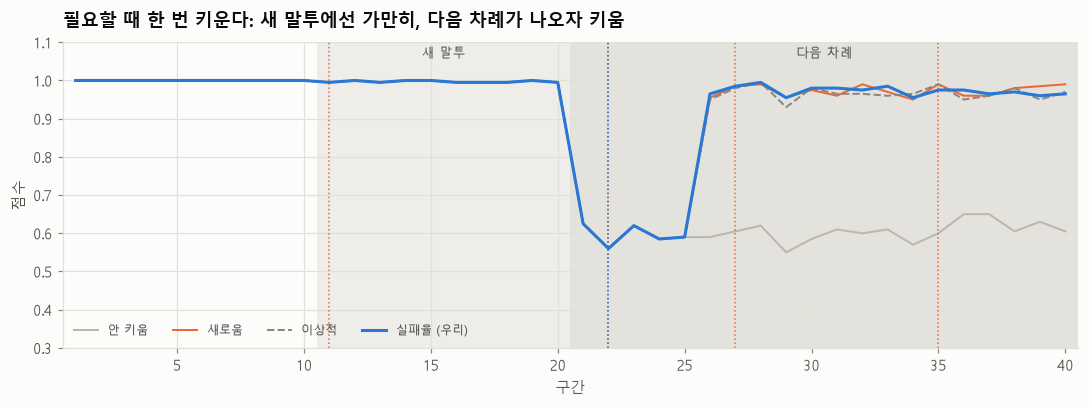

In [2]:

r = runs[45]["results"]
styles = [("never", "안 키움", V.NEUTRAL), ("novelty", "새로움", V.ORANGE), ("oracle", "이상적", V.MUTED), ("failure", "실패율 (우리)", V.BLUE)]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.axvspan(10.5, 20.5, color=V.GRID, alpha=0.5, lw=0)
ax.axvspan(20.5, 40.5, color=V.GRID, alpha=0.9, lw=0)
ax.text(15.5, 1.06, "새 말투", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.text(30.5, 1.06, "다음 차례", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
for key, label, color in styles:
    blocks = r[key]["blocks"]
    ax.plot([e["block"] for e in blocks], [e["score"] for e in blocks], color=color, lw=2 if key == "failure" else 1.3,
            ls="--" if key == "oracle" else "-", label=label)
    for g in r[key]["growths"]:
        if key in ("failure", "novelty"):
            ax.axvline(g["decided_at"], color=color, ls=":", lw=1)
ax.set_xlim(0.5, 40.5)
ax.set_ylim(0.3, 1.1)
ax.set_xlabel("구간")
ax.set_ylabel("점수")
ax.legend(fontsize=8, frameon=False, loc="lower left", ncol=4)
ax.set_title("필요할 때 한 번 키운다: 새 말투에선 가만히, 다음 차례가 나오자 키움", pad=10)
fig.tight_layout()
plt.show()



## 2. 무엇을 보고 결정했나 (seed 45)

빨간 점선이 문턱(5%)이다. 실패율은 새 말투 구간에서 0에 가깝고, 다음 차례 구간에서 40%로 뛴다. 새로움은 두 구간 모두에서 뛴다.


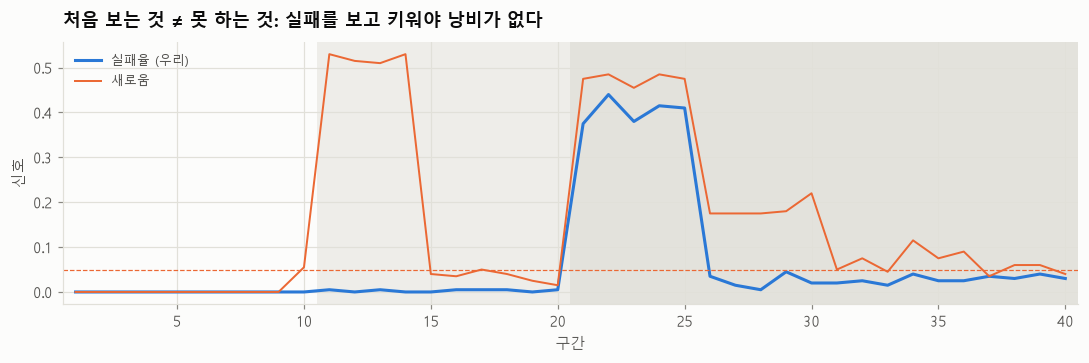

In [3]:

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot([e["block"] for e in r["failure"]["blocks"]], [e["signal"] for e in r["failure"]["blocks"]], color=V.BLUE, lw=2, label="실패율 (우리)")
ax.plot([e["block"] for e in r["novelty"]["blocks"]], [e["signal"] for e in r["novelty"]["blocks"]], color=V.ORANGE, lw=1.3, label="새로움")
ax.axhline(0.05, color=V.ORANGE, ls="--", lw=0.8)
ax.axvspan(10.5, 20.5, color=V.GRID, alpha=0.5, lw=0)
ax.axvspan(20.5, 40.5, color=V.GRID, alpha=0.9, lw=0)
ax.set_xlim(0.5, 40.5)
ax.set_xlabel("구간")
ax.set_ylabel("신호")
ax.legend(fontsize=8.5, frameon=False, loc="upper left")
ax.set_title("처음 보는 것 ≠ 못 하는 것: 실패를 보고 키워야 낭비가 없다", pad=10)
fig.tight_layout()
plt.show()



## 3. 몇 번 키웠나 (seed 3개)


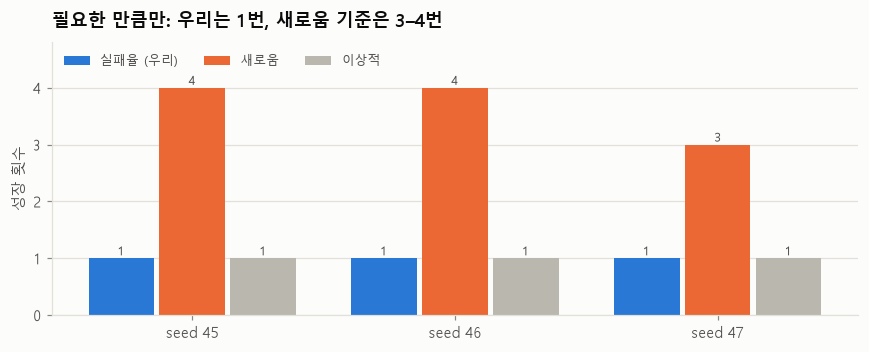

In [4]:

fig, ax = plt.subplots(figsize=(8, 3.3))
x = np.arange(3)
for i, (key, label, color) in enumerate([("failure", "실패율 (우리)", V.BLUE), ("novelty", "새로움", V.ORANGE), ("oracle", "이상적", V.NEUTRAL)]):
    counts = [len(runs[s]["summary"][key]["growths"]) for s in SEEDS]
    ax.bar(x + (i - 1) * 0.27, counts, width=0.25, color=color, label=label)
    for xi, c in zip(x, counts):
        ax.text(xi + (i - 1) * 0.27, c + 0.05, str(c), ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.set_ylim(0, 4.8)
ax.grid(axis="x", visible=False)
ax.set_ylabel("성장 횟수")
ax.legend(fontsize=8.5, frameon=False, ncol=3, loc="upper left")
ax.set_title("필요한 만큼만: 우리는 1번, 새로움 기준은 3–4번", pad=10)
fig.tight_layout()
plt.show()



## 4. 정리

- **졸업.** 세 seed 모두 새 말투 구간에서는 키우지 않았다. 다음 차례가 나오자 구간 22에 **딱 한 번** 키우기로 결정했다(이상적과 같은 시점). 구간 31–40 점수는 0.971 / 0.954 / 0.993으로, 이상적(0.966 / 0.984 / 0.978)과 비슷하다.
- **새로움 기준은 낭비했다.** 처음 보는 말투에도 반응해서 구간 11–12에 키웠고, 총 3–4번 키웠다.
- **실패에서 배운 것 두 가지**:
  1. 가지 학습이 다섯 번 실패했다. "문장 하나는 연결 하나를 말한다"를 구조로 넣자 0.2에서 0.997로 풀렸다.
  2. 성장 신호를 "확신하고 틀림"으로 했더니, 못 할 때 "모름"이라고 하는 seed에서 한 번도 키우지 않았다. "**모른다고 했는데 답이 있었다**"도 실패로 세야 한다.
- 한계: 새 능력의 모양(열쇠 한 칸 돌리기)과 성장 문턱은 사람이 정했다. 시스템이 정한 것은 언제 키울지와, 키울 때 무엇을 배울지다.
